In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
import sys, os 

sys.path.append(os.path.join("..", "src"))
from msvar import em_fit, build_regressors




## Description

- Goal: implement MVO to determine optimal portfolio weights with state-conditional asset returns and covariance matrix
- Methodology:
  - Step 1: Use 13 macroeconomic indicators to classify states (number of states initially set to be 2)
  - Step 2: Once states are classified (according to sorted probabilities), estimate the the state-conditional covariance matrix using Ledoit-Wolf's shrinkage method.
  - Step 3: Implement MVO for each of the states to determine optimal portfolio weights (for a portfolio three assets: equity, bond and gold)
  - Step 4: Backtest on historical test data and compare with 60/40 and equally weighted portfolios 

- Theoretical framework for Step 1: Two related hidden models
  - Plain vanilla HMM where conditional on the states which are assumed to follow a Markov chain, the observables are iid (Gaussian, for e.g.)
  - Markov Switching model (MSM): Even conditional on the states, the observables are allowed to exhibit serial correlation (for e.g., follow a VAR(1)). When both the mean and the covariance matrix are state-dependent, the model is called Markov Switching Mean Heteroskedastic Vector Autoregression (MSMH-VAR)

In this notebook, we will be implementing Steps 1-4 for the **MSMH-VAR(1)** model using the custom `msvar.py` module.

The key difference from the HMM notebook is the emission model. Conditional on state $k$, the macro indicators follow a **VAR(1)** process:

$$y_t = \mu^{(k)} + A_1^{(k)} y_{t-1} + \varepsilon_t^{(k)}, \quad \varepsilon_t^{(k)} \sim \mathcal{N}(0, \Sigma^{(k)})$$

rather than being i.i.d. draws from $\mathcal{N}(\mu^{(k)}, \Sigma^{(k)})$. The Hamilton filter and Kim smoother are identical to the HMM case — only the emission density changes.

## Data Preparation

We standardize the data before passing to the MSMH-VAR model. The VAR emission likelikehood is sensitive to scale for the reason as the HMM, i.e., having vastly different scales might lead to poorly conditioned covariance matrix and convergence of the EM algorithmm difficult. Note that unlike the HMM, the MSMH-VAR(p) consumes $p$ observations as initial lags so the effective sample size is $T-p$. With $p=1$ this means we lose one observation at the start of the series.

In [2]:
def prepare_macro_data(macro_df, train_end_idx: int = None):
    """
    Standardize macro indicators and split into train / test.


    Parameters
    ----------
    macro_df      : pd.DataFrame (T, n) — raw macro indicators
    train_end_idx : int — last training index; if None, use all data

    Returns
    -------
    X_train      : (T_train, n) standardized training array
    X_test       : (T_test, n) standardized test array, or None
    scaler       : fitted StandardScaler
    dates_train  : DatetimeIndex
    dates_test   : DatetimeIndex or None
    """
    values = macro_df.values.astype(float)
    dates  = macro_df.index

    if train_end_idx is None:
        train_end_idx = len(values)

    X_raw_train = values[:train_end_idx]
    X_raw_test  = values[train_end_idx:] if train_end_idx < len(values) else None

    # Fit scaler on training data ONLY
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_raw_train)
    X_test  = scaler.transform(X_raw_test) if X_raw_test is not None else None

    dates_train = dates[:train_end_idx]
    dates_test  = dates[train_end_idx:] if X_raw_test is not None else None

    return X_train, X_test, scaler, dates_train, dates_test

In [4]:
data_path = os.path.join("..", "data")
macro_df = pd.read_csv(os.path.join(data_path, "macro_clean.csv"), index_col=0, parse_dates=True)

In [5]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   cpi                     431 non-null    float64
 5   oil_price               431 non-null    float64
 6   vix                     431 non-null    float64
 7   credit_spread           431 non-null    float64
 8   yield_curve_slope       431 non-null    float64
 9   fed_funds_rate          431 non-null    float64
 10  consumer_sentiment      431 non-null    float64
 11  housing_starts          431 non-null    float64
 12  m2_money_supply         431 non-null    float64
dtypes: float64(13)
memory usage: 47.1 KB


In [6]:
# Use all data for regime detection (no train/test split on macro indicators)
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)

## Model fitting

We fit the MSMH-VAR(K=2, p=1) model to the standardized training data via the EM algorithm (Hamilton filter + Kim smoother + weighted OLS).

**Key difference from HMM fitting**  
`em_fit` runs the full EM loop internally with multiple random restarts. Each restart initializes parameters via K-means clustering on VAR residuals. The best solution (highest log-likelihood) is retained.

**Parameter count warning**  
With $n=13$ indicators and $p=1$, each regime has $n \times (np+1) = 13 \times 14 = 182$ VAR coefficients plus $n(n+1)/2 = 91$ covariance parameters — 273 per regime, 546 total for $K=2$. This is tight relative to $T \approx 300$ monthly observations.

In [7]:
result = em_fit(
    data=X_train,
    K=2,
    p=1,
    n_restarts=5,
    max_iter=300,
    tol=1e-6,
    random_state=42,
    verbose=True
)


--- Restart 1/5 ---
  iter    0 | log-lik = -4285.596643 | Δ = inf
  iter   10 | log-lik = -3693.326422 | Δ = 9.63e+00
  iter   20 | log-lik = -3690.651710 | Δ = 1.91e-06
  Converged at iteration 21.

--- Restart 2/5 ---
  iter    0 | log-lik = -4299.339304 | Δ = inf
  iter   10 | log-lik = -3693.197903 | Δ = 7.04e+00
  iter   20 | log-lik = -3690.651710 | Δ = 1.80e-06
  Converged at iteration 21.

--- Restart 3/5 ---
  iter    0 | log-lik = -4280.217814 | Δ = inf
  iter   10 | log-lik = -3696.957745 | Δ = 8.21e+00
  iter   20 | log-lik = -3690.651711 | Δ = 3.15e-06
  Converged at iteration 22.

--- Restart 4/5 ---
  iter    0 | log-lik = -4393.275276 | Δ = inf
  iter   10 | log-lik = -3749.136201 | Δ = 3.88e-01
  iter   20 | log-lik = -3710.515534 | Δ = 4.54e-03
  Converged at iteration 23.

--- Restart 5/5 ---
  iter    0 | log-lik = -4577.235162 | Δ = inf
  Converged at iteration 9.


In [8]:
result.summary()

MSMH-VAR(2, 1)  |  n=13, T=430
Log-likelihood : -3637.9252
AIC            : 8371.8504
BIC            : 10598.8047
# parameters   : 548
EM iterations  : 10

Transition Matrix P (row i -> col j):
[[0.7869 0.2131]
 [0.0177 0.9823]]

Expected Regime Durations (periods):
  Regime 0: 4.7
  Regime 1: 56.4

Effective Sample Sizes:
  Regime 0: 33.0 obs (7.7%)
  Regime 1: 397.0 obs (92.3%)

--- Regime 0 VAR Intercept (mu) ---
[-0.594072  0.599912 -0.33258   0.344527  0.171129 -0.447197  0.978732
  0.240507  0.169415 -0.403536  0.102526 -0.116413  0.953095]
--- Regime 0 Covariance Sigma ---
[[ 1.330546e+00  4.957920e-01 -2.772770e-01 -9.157040e-01  1.096270e-01
   4.549430e-01 -4.558490e-01 -2.045700e-01 -2.012200e-02  8.146200e-02
  -6.139100e-02  6.858500e-01 -3.009680e-01]
 [ 4.957920e-01  1.049796e+00 -3.593490e-01 -1.049174e+00 -6.441500e-02
   3.975550e-01 -3.568810e-01 -1.510180e-01 -1.642700e-02  3.086740e-01
   2.238820e-01  2.761440e-01 -3.776790e-01]
 [-2.772770e-01 -3.593490e-01  4.79

## Results extraction

### Smoothed probabilities

Smoothed probabilities are the probabilities of being in a certain state given the full observation sequence. In particular:
$$
\gamma_t(k) = P(S_t = k \mid y_{1:T}).
$$

They are use  for in-sample analysis and backtesting where the full history is available.

Here they are stored in `result.xi_smoothed` which can be accessed once the model is fitted.

In [11]:
smoothed_probs = result.xi_smoothed
smoothed_probs.shape

(2, 430)

In [23]:
# Verify that probabilities sum to 1 across regimes for each time point
prob_sums = smoothed_probs.sum(axis=0)
np.allclose(prob_sums, 1.0)

True

In [21]:
smoothed_probs_df = pd.DataFrame(
    smoothed_probs.T, 
    index=dates_train[1:],  # first date corresponds to t=1 (after lag)
    columns=[f"Regime {i}" for i in range(smoothed_probs.shape[0])]
)


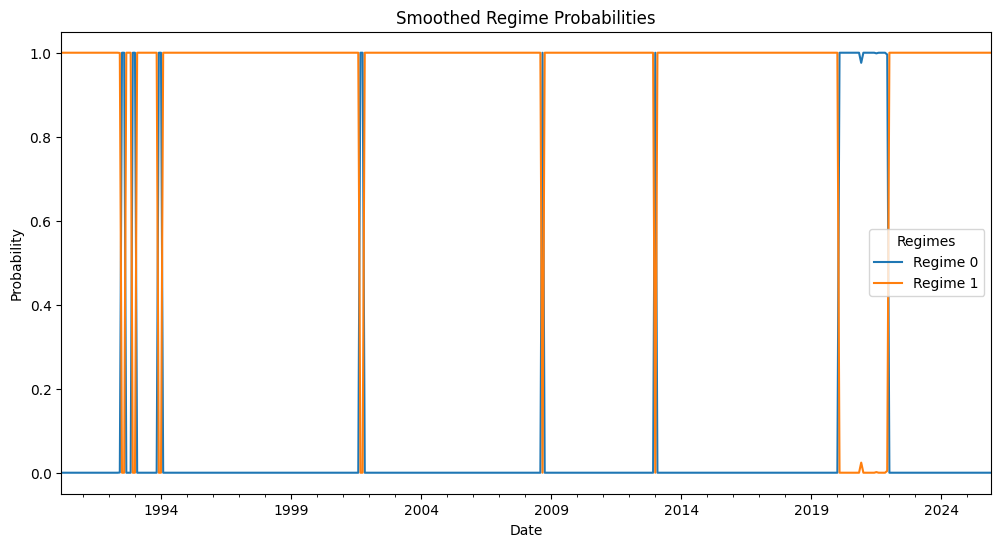

In [22]:
smoothed_probs_df.plot(figsize=(12, 6))
plt.title("Smoothed Regime Probabilities")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend(title="Regimes")
plt.show()

### Filtered probabilities

Filtered probabilities are probabilites of being in a certain state conditional upon past observations only. In particular:
$$
P(S_t = k | y_{1:t}).
$$

They are used for live / out-of-sample allocation.

They can be accessed post-estimation via `result.xi_filtered`.

In [24]:
filtered_probs = result.xi_filtered
filtered_probs.shape

(2, 430)

In [25]:
# check that filtered probabilities also sum to 1 across regimes
filtered_prob_sums = filtered_probs.sum(axis=0)
np.allclose(filtered_prob_sums, 1.0)

True

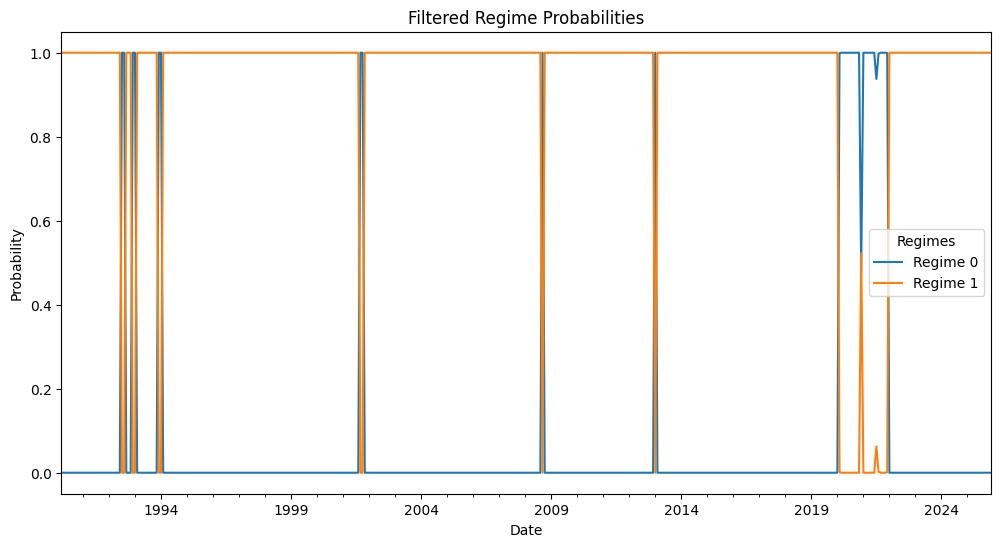

In [27]:
filtered_probs_df = pd.DataFrame(
    filtered_probs.T, 
    index=dates_train[1:],  # first date corresponds to t=1 (after lag)
    columns=[f"Regime {i}" for i in range(filtered_probs.shape[0])]
)

filtered_probs_df.plot(figsize=(12, 6))
plt.title("Filtered Regime Probabilities")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend(title="Regimes")
plt.show()